We use `telco_churn_with_all_feedback.csv` because it represents a realistic, raw dataset
containing missing values, noisy text, and mixed data types. This allows us to demonstrate
data cleaning, preprocessing, and exploratory data analysis steps that are essential in
real-world data science workflows.

In [1]:
import pandas as pd

df = pd.read_csv('telco_churn_with_all_feedback.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Write a realistic customer feedback based on t...,I have been a loyal customer with this company...
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Write a realistic customer feedback based on t...,I recently switched to this fiber optic intern...


### Initial Data Observations

- The dataset contains 23 features with a mix of numerical, categorical, and text-based data.
- The target variable is `Churn`, which has two possible values (Yes/No), confirming this is a binary classification problem.
- Identifier columns such as `customerID` do not provide predictive value and will be removed.
- Text-based columns (`PromptInput`, `CustomerFeedback`) represent unstructured data and require advanced NLP techniques, which are outside the scope of this project.

Next we answer, "What does my data look like, and what problems might exist?”

In [2]:
df.shape

(7043, 23)

The dataset contains 7,043 customer records with 23 features, which is a realistic size for a customer churn prediction task.

Why this matters?

1. Large enough to train models
2. Small enough to explore visually

3. Suggests this is real-world data, not toy data

The following is the most important inspection command (df.info())

Insight:

Most features are categorical or text-based, meaning encoding will be required before modeling

Critical Data Quality Issue Identified:

TotalCharges is incorrectly stored as an object, indicating data quality issues that must be addressed during cleaning. TotalCharges should be numeric.

This will break models if not fixed

Also, the Identifier Column:

Identifier columns such as customerID should be removed because they do not contribute meaningful information to prediction

For this project:

Text features are excluded to focus on structured data and traditional machine learning techniques. (ex. PromptInput, CustomerFeedback)

Important observation:

7043 non-null

Meaning:

No explicit missing values

BUT data may still contain hidden missing values (e.g., empty strings)

Even when non-null counts are equal, further checks are required to detect hidden missing values.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Below, df.describe() summarizes numeric columns only

Binary categorical variables stored as numeric should be treated carefully during modeling

Customers with shorter tenure are often more likely to churn

Higher monthly charges may increase churn risk due to perceived cost burden

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Data Inspection Summary

- The dataset contains 7,043 customer records and 23 features.
- Most variables are categorical, indicating that encoding will be required.
- The `TotalCharges` feature is incorrectly stored as an object, suggesting hidden data quality issues.
- Identifier columns such as `customerID` do not provide predictive value and should be removed.
- No explicit missing values are present, but further checks are required for hidden missing data.

In [5]:
# customerID is a unique identifier and does not contain predictive information
# Keeping it would add noise and could negatively impact model performance
df.drop(columns=['customerID'], inplace=True)

In [6]:
# Stripping column names ensures consistency and prevents potential errors
# caused by hidden whitespace in column headers
df.columns = df.columns.str.strip()

In [7]:
# TotalCharges should be numeric, but is stored as an object
# errors='coerce' converts invalid values to NaN so they can be handled properly
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [8]:
# Median is used to handle missing values because it is robust to outliers
# and appropriate for skewed financial data
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_7863/952106447.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [9]:
# Verify that missing values have been handled
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


EDA (Exploratory Data Analysis)

Target Variable Distribution:

Why this is important?

Identifies class imbalance

Informs metric choice later (precision, recall, F1, ROC-AUC)

Accuracy alone may be misleading when the target variable is imbalanced.

In [10]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


Below we, churn by Contract Type

Why this is strong?

1. Converts churn into a numeric rate

2. Easy to interpret

3. Perfect for business insight

Customers on month-to-month contracts churn significantly more than those on one-year or two-year contracts

In [11]:
df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean())

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


Numerical Feature Distribution

What so we analyze below?

1. Skewness

2. Spending clusters

3. Potential outliers

Interpretation example:

Monthly charges appear right-skewed, indicating most customers pay lower monthly fees, with fewer high-paying customers.

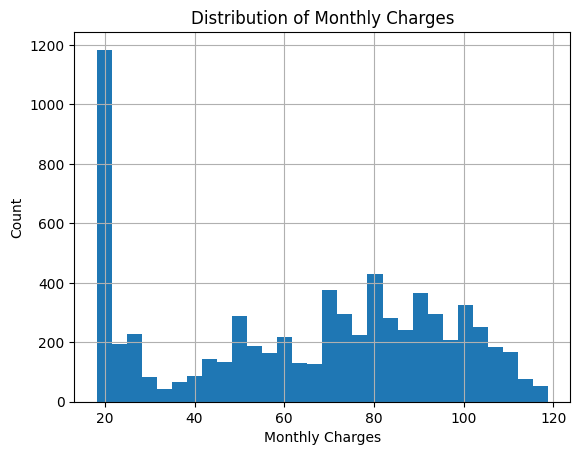

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns  # for more advanced plots later

df['MonthlyCharges'].hist(bins=30)
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()

### Analysis of Monthly Charges Distribution

- The histogram shows that monthly charges are **right-skewed**, meaning most customers pay lower fees, while fewer customers pay very high fees.
- There appear to be **clusters** of spending, which may correspond to different service levels (basic vs. premium).
- Potential **outliers** at the high end represent customers paying unusually high fees.
- These patterns are important because they may influence churn:
    - High-paying outliers may churn if they perceive poor value.
    - Spending clusters allow us to segment customers and analyze churn rates within each group.


Below, we combine MonthlyCharges and Churn using a boxplot, which will directly answer our churn question visually

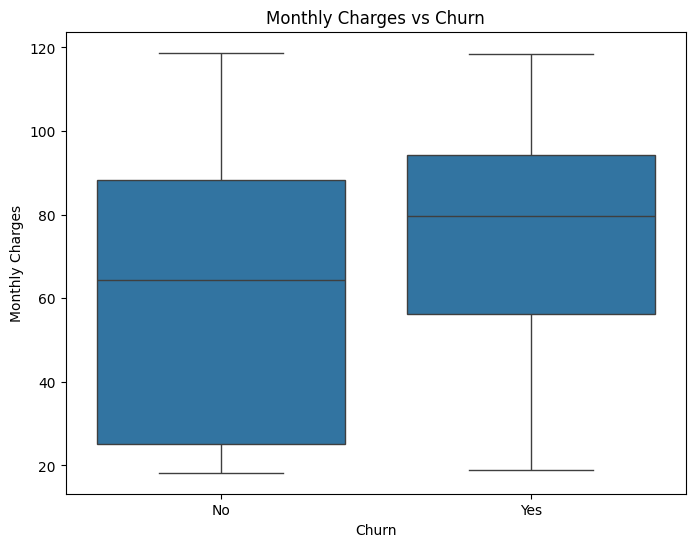

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Monthly Charges vs Churn

- Boxplot shows that customers who churn tend to have slightly higher monthly charges than non-churners.
- There are some outliers in the churn group, indicating a small number of high-paying customers leave.
- This insight helps understand which customers are at higher risk of leaving and informs feature engineering for modeling.

# DAY 2: Feature Engineering + Baseline Modeling
# Applied Data Science Capstone — Customer Churn

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

Ordinal Encoding

Map ordered categories to numbers:

Use ordinal encoding only for features with natural order

In [15]:
ordinal_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(ordinal_map)

# Verify
df[['Contract']].head()

,Contract
0,0
1,1
2,0
3,1
4,0


One-Hot Encoding

Encode unordered categorical variables:

One-hot avoids false order. drop_first=True prevents multicollinearity

In [16]:
categorical_cols = ['gender', 'InternetService', 'PaymentMethod']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#Verify
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,Churn,PromptInput,CustomerFeedback,gender_Male,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,Yes,No,1,No,No phone service,No,Yes,No,No,...,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...,False,False,False,False,True,False
1,0,No,No,34,Yes,No,Yes,No,Yes,No,...,1889.50,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...,True,False,False,False,False,True
2,0,No,No,2,Yes,No,Yes,Yes,No,No,...,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...,True,False,False,False,False,True
3,0,No,No,45,No,No phone service,Yes,No,Yes,Yes,...,1840.75,No,Write a realistic customer feedback based on t...,I have been a loyal customer with this company...,True,False,False,False,False,False
4,0,No,No,2,Yes,No,No,No,No,No,...,151.65,Yes,Write a realistic customer feedback based on t...,I recently switched to this fiber optic intern...,False,True,False,False,True,False


Encode Target Variable

Always check for class imbalance. If one class dominates, accuracy alone will be misleading

In [17]:
# Convert 'Churn' to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Check distribution
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


Train/Test Split

Ensure train/test split looks reasonable (e.g., 80/20 of total rows)

In [19]:
# Separate features and target
X = df.drop('Churn', axis=1)  # All columns except target
y = df['Churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify shapes
X_train.shape, X_test.shape

((5634, 24), (1409, 24))

In [20]:
# Always verify your X_train.dtypes before modeling

print(X_train.dtypes)

SeniorCitizen                              int64
Partner                                   object
Dependents                                object
tenure                                     int64
PhoneService                              object
MultipleLines                             object
OnlineSecurity                            object
OnlineBackup                              object
DeviceProtection                          object
TechSupport                               object
StreamingTV                               object
StreamingMovies                           object
Contract                                   int64
PaperlessBilling                          object
MonthlyCharges                           float64
TotalCharges                             float64
PromptInput                               object
CustomerFeedback                          object
gender_Male                                 bool
InternetService_Fiber optic                 bool
InternetService_No  

Columns like SeniorCitizen, tenure, Contract, MonthlyCharges, TotalCharges → numeric = **Very Good**

Columns like Partner, Dependents, PhoneService, MultipleLines, OnlineSecurity, etc. → object = **Problematic**

Columns like PromptInput and CustomerFeedback → object/text = **Problematic**

Columns like gender_Male, InternetService_Fiber optic, etc. → bool = **Works**(fine for models)

Convert remaining Yes/No columns

This converts all object columns that have 'Yes'/'No' (and special cases like 'No phone service') to numeric 0/1, making them compatible with Logistic Regression

In [21]:
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})

In [22]:
# Now all these columns are numeric (int64)
#  Always verify your X_train.dtypes before modeling

print(X_train.dtypes)

SeniorCitizen                              int64
Partner                                   object
Dependents                                object
tenure                                     int64
PhoneService                              object
MultipleLines                             object
OnlineSecurity                            object
OnlineBackup                              object
DeviceProtection                          object
TechSupport                               object
StreamingTV                               object
StreamingMovies                           object
Contract                                   int64
PaperlessBilling                          object
MonthlyCharges                           float64
TotalCharges                             float64
PromptInput                               object
CustomerFeedback                          object
gender_Male                                 bool
InternetService_Fiber optic                 bool
InternetService_No  

Drop text-only columns

Columns like PromptInput and CustomerFeedback are free-form text. Logistic Regression cannot process raw text without NLP preprocessing (like TF-IDF). Since we are not doing NLP here, dropping them removes the remaining object columns that would cause errors.

In [23]:
df = df.drop(['PromptInput', 'CustomerFeedback'], axis=1)

In [24]:
# Now all these columns are numeric (int64)
#  Always verify your X_train.dtypes before modeling

print(X_train.dtypes)

SeniorCitizen                              int64
Partner                                   object
Dependents                                object
tenure                                     int64
PhoneService                              object
MultipleLines                             object
OnlineSecurity                            object
OnlineBackup                              object
DeviceProtection                          object
TechSupport                               object
StreamingTV                               object
StreamingMovies                           object
Contract                                   int64
PaperlessBilling                          object
MonthlyCharges                           float64
TotalCharges                             float64
PromptInput                               object
CustomerFeedback                          object
gender_Male                                 bool
InternetService_Fiber optic                 bool
InternetService_No  

After cleaning df (mapping Yes/No → 1/0 and dropping text columns), you must re-run the train/test split on the updated df:

At which point all columns should be numeric (int64, float64, bool) and no object types remain

In [25]:
# Running the following code a second time to debug an issue that was causing an error in the following code

# Separate features and target again after cleaning
X = df.drop('Churn', axis=1)
y = df['Churn']

# Re-run train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify dtypes
print(X_train.dtypes)

SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
Contract                                   int64
PaperlessBilling                          object
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electr

In [26]:
# Include PaperlessBilling in yes/no mapping
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

# Map Yes/No to 1/0
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})

# Verify
print(df['PaperlessBilling'].value_counts())
print(df['PaperlessBilling'].dtype)

PaperlessBilling
1    4171
0    2872
Name: count, dtype: int64
int64


In [27]:
# Running the following code a third time to debug an issue that was causing an error in the following code

# Separate features and target again after cleaning
X = df.drop('Churn', axis=1)
y = df['Churn']

# Re-run train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify dtypes
print(X_train.dtypes)

SeniorCitizen                              int64
Partner                                  float64
Dependents                               float64
tenure                                     int64
PhoneService                             float64
MultipleLines                            float64
OnlineSecurity                           float64
OnlineBackup                             float64
DeviceProtection                         float64
TechSupport                              float64
StreamingTV                              float64
StreamingMovies                          float64
Contract                                   int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electr

How to check for NaNs

Quickly see which columns have missing values

In [28]:
# Count missing values per column
print(X_train.isna().sum())

print()

# Check the percentage
print(X_train.isna().mean() * 100)

SeniorCitizen                               0
Partner                                  5634
Dependents                               5634
tenure                                      0
PhoneService                             5634
MultipleLines                            5634
OnlineSecurity                           5634
OnlineBackup                             5634
DeviceProtection                         5634
TechSupport                              5634
StreamingTV                              5634
StreamingMovies                          5634
Contract                                    0
PaperlessBilling                            0
MonthlyCharges                              0
TotalCharges                                0
gender_Male                                 0
InternetService_Fiber optic                 0
InternetService_No                          0
PaymentMethod_Credit card (automatic)       0
PaymentMethod_Electronic check              0
PaymentMethod_Mailed check        

In [29]:
# Investigate why they became NaN

print(df['Partner'].unique())

[nan]


In [30]:
# Drop any text columns if they exist (safe to run multiple times)
df = df.drop(['PromptInput', 'CustomerFeedback'], axis=1, errors='ignore')

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify all numeric and no missing values
print(X_train.dtypes)
print(X_train.isna().sum())  # Should be all 0

SeniorCitizen                              int64
Partner                                  float64
Dependents                               float64
tenure                                     int64
PhoneService                             float64
MultipleLines                            float64
OnlineSecurity                           float64
OnlineBackup                             float64
DeviceProtection                         float64
TechSupport                              float64
StreamingTV                              float64
StreamingMovies                          float64
Contract                                   int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electr

Rebuild X and y from the current df

In [32]:
# Final sanity check
print(df.isna().sum())

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.isna().sum())

SeniorCitizen                               0
Partner                                  7043
Dependents                               7043
tenure                                      0
PhoneService                             7043
MultipleLines                            7043
OnlineSecurity                           7043
OnlineBackup                             7043
DeviceProtection                         7043
TechSupport                              7043
StreamingTV                              7043
StreamingMovies                          7043
Contract                                    0
PaperlessBilling                            0
MonthlyCharges                              0
TotalCharges                                0
Churn                                       0
gender_Male                                 0
InternetService_Fiber optic                 0
InternetService_No                          0
PaymentMethod_Credit card (automatic)       0
PaymentMethod_Electronic check    

Drop the dead columns

Logistic Regression:

1. Cannot accept NaN values

2. Requires fully numeric, complete data

3. Even a single NaN in any column causes failure


In [33]:
df = df.drop([
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
], axis=1)

In [ ]:
# Final sanity check
print(df.isna().sum())

SeniorCitizen                            0
tenure                                   0
Contract                                 0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
InternetService_Fiber optic              0
InternetService_No                       0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
dtype: int64


In [34]:
print(X_train.isna().sum())

SeniorCitizen                               0
Partner                                  5634
Dependents                               5634
tenure                                      0
PhoneService                             5634
MultipleLines                            5634
OnlineSecurity                           5634
OnlineBackup                             5634
DeviceProtection                         5634
TechSupport                              5634
StreamingTV                              5634
StreamingMovies                          5634
Contract                                    0
PaperlessBilling                            0
MonthlyCharges                              0
TotalCharges                                0
gender_Male                                 0
InternetService_Fiber optic                 0
InternetService_No                          0
PaymentMethod_Credit card (automatic)       0
PaymentMethod_Electronic check              0
PaymentMethod_Mailed check        

In [35]:
df = df.drop([
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
], axis=1, errors='ignore')

print(df.columns)

Index(['SeniorCitizen', 'tenure', 'Contract', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male',
       'InternetService_Fiber optic', 'InternetService_No',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


Train Logistic Regression AGAIN

In [36]:
# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Final check (should all be 0)
print(X_train.isna().sum())

# Train Logistic Regression
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

SeniorCitizen                            0
tenure                                   0
Contract                                 0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
InternetService_Fiber optic              0
InternetService_No                       0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
dtype: int64


Baseline Models

1. Logistic Regression

Check coefficients with log_model.coef_ to see which features most affect churn probability

In [37]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Evaluate
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Performance
Accuracy: 0.808374733853797
Precision: 0.6470588235294118
Recall: 0.5726027397260274
F1 Score: 0.6075581395348837

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87      1044
           1       0.65      0.57      0.61       365

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline Models

2. Decision Tree Classifier

In [38]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Evaluate
print("Decision Tree Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

Decision Tree Performance
Accuracy: 0.7253371185237757
Precision: 0.4723618090452261
Recall: 0.5150684931506849
F1 Score: 0.4927916120576671

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      1044
           1       0.47      0.52      0.49       365

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409



Compare Logistic Regression vs Decision Tree: linear vs nonlinear performance, overfitting risk, baseline understanding

1. Logistic regression shows linear relationships — good first approximation.

2. Decision tree can model non-linear interactions, but may overfit training data if not pruned.

3. Comparing the two gives a baseline understanding of model performance before moving to advanced models like Random Forest or XGBoost.

Confusion Matrix Heatmap

Visualizes true positives, true negatives, false positives, false negatives for each model.

Shows which class the model predicts well or poorly.

Makes it obvious that churners (class 1) are harder to predict

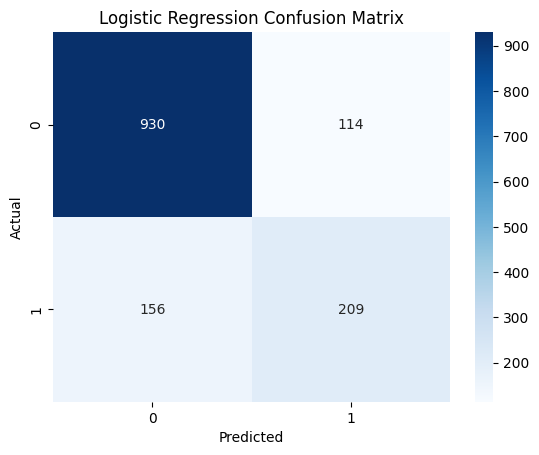

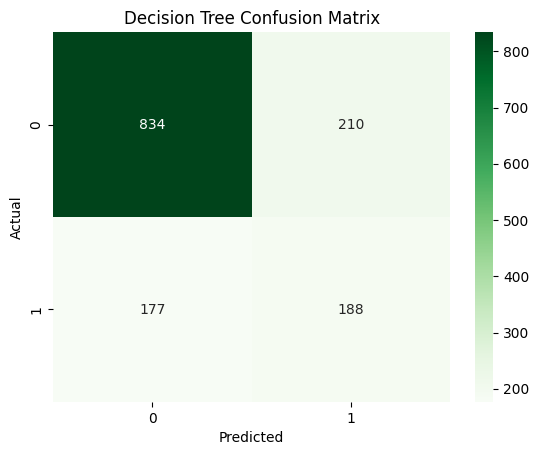

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Logistic Regression Confusion Matrix
# Benefit: You can immediately see which type of errors each model makes
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Decision Tree Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

Bar plot of evaluation metrics

Compare accuracy, precision, recall, F1 side by side for both models

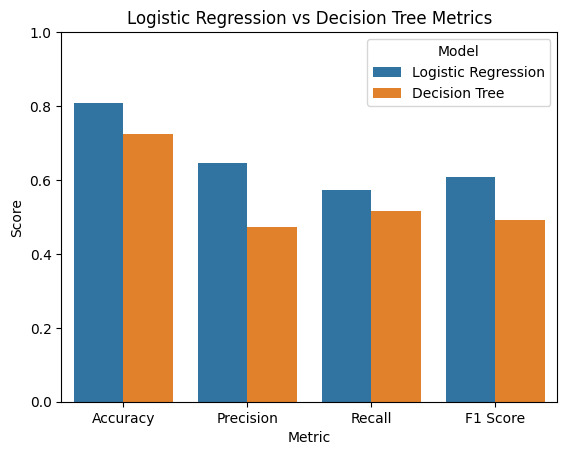

In [40]:
import pandas as pd

# Benefit: You can quickly see which model performs better on each metric and highlight the trade-offs
metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log)
    ],
    'Decision Tree': [
        accuracy_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_tree)
    ]
})

metrics_melted = metrics.melt(id_vars='Metric', var_name='Model', value_name='Score')

sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model')
plt.ylim(0,1)
plt.title('Logistic Regression vs Decision Tree Metrics')
plt.show()

ROC Curve

Shows how well the model separates churners from non-churners across all thresholds.

Can compare the Area Under the Curve (AUC) for each model

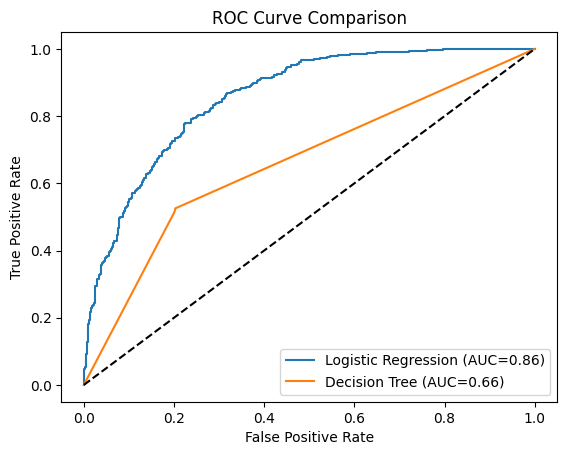

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

# Benefit: A high AUC means the model is good at distinguishing churners from non-churners

# Logistic Regression ROC
y_prob_log = log_model.predict_proba(X_test)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# Decision Tree ROC
y_prob_tree = tree_model.predict_proba(X_test)[:,1]
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC={auc_tree:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

Summary:

Confusion matrix → shows exact errors

Bar plot → compares metrics visually

ROC curve → shows model discrimination power

Day 3

Model Tuning + Evaluation

Imbalanced Data Awareness

Before tuning models, always check your target variable distribution to understand class imbalance

In [42]:
# Check Churn imbalance
churn_distribution = df['Churn'].value_counts(normalize=True)
print(churn_distribution)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


Cross-Validation (CV)

Use cross-validation to get more reliable performance estimates on your training set

K-Fold CV splits the training data into k subsets, trains the model on k-1 folds, and validates on the remaining fold. This repeats k times.

Reduces the risk of overfitting to one random train/test split.

Provides a better estimate of bias vs variance.

In [43]:
from sklearn.model_selection import cross_val_score

# Logistic Regression CV
log_cv_scores = cross_val_score(log_model, X_train, y_train, cv=5, scoring='f1')
print("Logistic Regression CV F1 scores:", log_cv_scores)
print("Mean F1:", log_cv_scores.mean())

# Decision Tree CV
tree_cv_scores = cross_val_score(tree_model, X_train, y_train, cv=5, scoring='f1')
print("Decision Tree CV F1 scores:", tree_cv_scores)
print("Mean F1:", tree_cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression CV F1 scores: [0.55743879 0.60035524 0.56529517 0.58195212 0.59469697]
Mean F1: 0.5799476584041618
Decision Tree CV F1 scores: [0.46905537 0.53905054 0.46962233 0.49917355 0.49140893]
Mean F1: 0.4936621461397584


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV for Hyperparameter Tuning

1. Logistic Regression

F1-score is preferred for imbalanced data because it balances Precision and Recall.

GridSearchCV automatically tests all hyperparameter combinations and selects the best-performing model using CV.

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define parameter grid
log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],       # Regularization strength
    'solver': ['lbfgs', 'liblinear']    # Different optimization algorithms
}

# GridSearchCV setup
log_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000),
    param_grid=log_param_grid,
    cv=5,
    scoring='f1'
)

log_grid.fit(X_train, y_train)

print("Best Logistic Regression Params:", log_grid.best_params_)
print("Best Logistic Regression F1:", log_grid.best_score_)

Best Logistic Regression Params: {'C': 10, 'solver': 'liblinear'}
Best Logistic Regression F1: 0.5845904690074987


GridSearchCV for Hyperparameter Tuning

2. Decision Tree

F1-score is preferred for imbalanced data because it balances Precision and Recall.

GridSearchCV automatically tests all hyperparameter combinations and selects the best-performing model using CV.

In [45]:
from sklearn.tree import DecisionTreeClassifier

# Define parameter grid
tree_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}

# GridSearchCV setup
tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_param_grid,
    cv=5,
    scoring='f1'
)

tree_grid.fit(X_train, y_train)

print("Best Decision Tree Params:", tree_grid.best_params_)
print("Best Decision Tree F1:", tree_grid.best_score_)

Best Decision Tree Params: {'max_depth': 5, 'min_samples_split': 5}
Best Decision Tree F1: 0.5730862782474695


Final Evaluation on Test Set

1. Predictions with Best Estimators

In [46]:
# Logistic Regression
best_log = log_grid.best_estimator_
y_pred_log = best_log.predict(X_test)
print(y_pred_log)

# Decision Tree
best_tree = tree_grid.best_estimator_
y_pred_tree = best_tree.predict(X_test)
print(y_pred_tree)

[1 1 0 ... 1 0 0]
[1 1 0 ... 1 0 0]


Final Evaluation on Test Set

2. Confusion Matrices

Confusion matrix shows True Positives (TP), True Negatives (TN), False Positives (FP), False Negatives (FN).

Helps identify which type of errors are most common

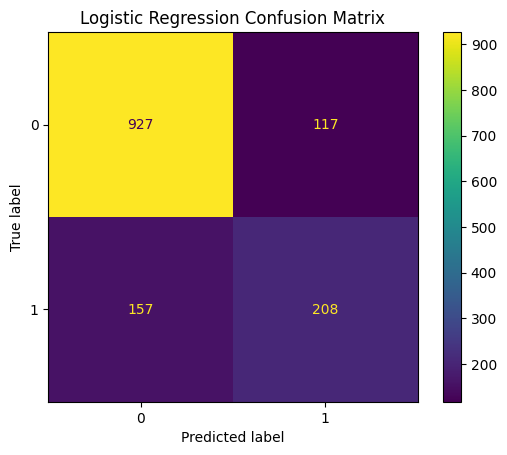

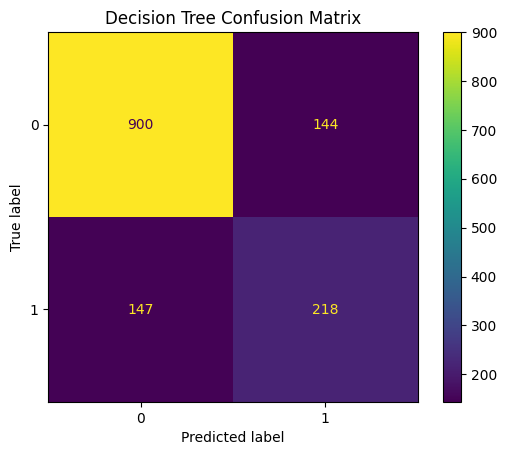

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression CM
ConfusionMatrixDisplay.from_estimator(best_log, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Decision Tree CM
ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test)
plt.title("Decision Tree Confusion Matrix")
plt.show()

Final Evaluation on Test Set

3. Classification Reports

Reports Precision, Recall, F1-score for each class.

Provides a detailed view of model performance beyond accuracy.

Compare models to select the one with the best tradeoff for business needs

In [48]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_log))

print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_tree))

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1044
           1       0.64      0.57      0.60       365

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1044
           1       0.60      0.60      0.60       365

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



Final Evaluation on Test Set

4. ROC Curve & AUC

ROC Curve shows the tradeoff between TPR (Recall) and FPR.

AUC measures the model's ability to distinguish classes; higher = better

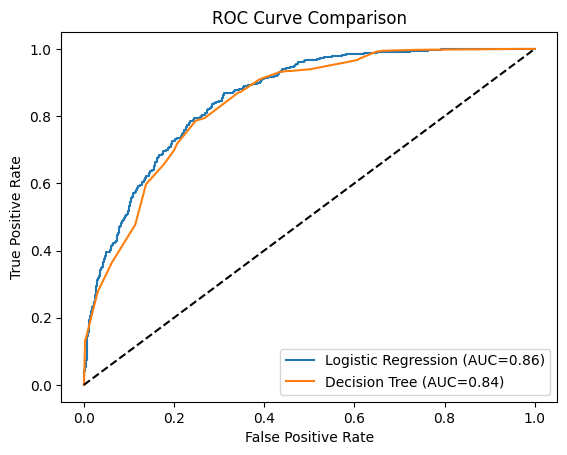

In [50]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilities
y_prob_log = best_log.predict_proba(X_test)[:, 1]
y_prob_tree = best_tree.predict_proba(X_test)[:, 1]

# ROC Curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_tree = roc_auc_score(y_test, y_prob_tree)

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC={auc_tree:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

This project demonstrates a full end-to-end workflow for a real-world classification problem:

Data Cleaning and EDA: Understanding the dataset and preparing features

Feature Engineering: Encoding categorical variables appropriately

Model Training and Tuning: Logistic Regression and Decision Tree with cross-validation and hyperparameter optimization

Evaluation and Interpretation: Metrics, confusion matrices, ROC-AUC, and business implications